In [1]:
import pandas as pd
from pathlib import Path

# load data from csv file
# "brokered_by" and "street" are not used in the analysis as they contain many unique values for identification

data_path = Path("data/USA Real Estate Dataset.csv")
usecols = [
    "price",
    "bed",
    "bath",
    "acre_lot",
    "city",
    "state",
    "house_size",
    "area_type",
    "price_per_sqft",
    "price_per_acre",
]


df = pd.read_csv(data_path, usecols=usecols)
print("Data loaded successfully")

df = df.copy()
df.head()

Data loaded successfully


,price,bed,bath,acre_lot,city,state,house_size,price_per_sqft,price_per_acre,area_type
0,105000.0,3,2,0.12,Adjuntas,Puerto Rico,920,114.13,875000.00,urban
1,80000.0,4,2,0.08,Adjuntas,Puerto Rico,1527,52.39,1000000.00,urban
2,67000.0,2,1,0.15,Juana Diaz,Puerto Rico,748,89.57,446666.67,urban
3,145000.0,4,2,0.10,Ponce,Puerto Rico,1800,80.56,1450000.00,urban
4,179000.0,4,3,0.46,San Sebastian,Puerto Rico,2520,71.03,389130.43,suburban


In [2]:
df.dtypes

price             float64
bed                 int64
bath                int64
acre_lot          float64
city                  str
state                 str
house_size          int64
price_per_sqft    float64
price_per_acre    float64
area_type             str
dtype: object

In [3]:
df.isnull().sum()

price             0
bed               0
bath              0
acre_lot          0
city              0
state             0
house_size        0
price_per_sqft    0
price_per_acre    0
area_type         0
dtype: int64

In [4]:
df.describe(percentiles=[.001,.01,.99,.995,.999]).T

,count,mean,std,min,0.1%,1%,99%,99.5%,99.9%,max
price,1471301.0,3.944898e+05,2.309146e+05,1.00,14900.000,45000.00,1049000.00,1099000.00,1.123193e+06,1147131.0
bed,1471301.0,3.173593e+00,1.206984e+00,1.00,1.000,1.00,6.00,7.00,1.000000e+01,444.0
bath,1471301.0,2.355775e+00,1.100148e+00,1.00,1.000,1.00,5.00,6.00,7.000000e+00,460.0
acre_lot,1471301.0,1.019645e+01,7.457050e+02,0.01,0.010,0.02,18.99,37.90,1.423920e+02,100000.0
house_size,1471301.0,1.892878e+03,3.747986e+03,100.00,400.000,619.00,4789.00,5419.00,7.576700e+03,1560780.0
price_per_sqft,1471301.0,2.280538e+02,1.502315e+02,0.00,10.730,33.94,794.51,921.34,1.242054e+03,6500.0
price_per_acre,1471301.0,2.587534e+06,4.427219e+06,0.00,2166.201,18005.54,21106500.00,28990000.00,5.000000e+07,114702300.0


-- Some of the variables have extreme heavy tails and some data point just shows unreasonable in reality, which will be deleted or winsorize it to the nearby percentile.

In [5]:
from src.data import handle_extreme_values
#handle extreme values
df = handle_extreme_values(df)
df.describe(percentiles=[.01,.25,.5,.75,.99]).T


,count,mean,std,min,1%,25%,50%,75%,99%,max
price,1470435.0,3.944403e+05,2.293933e+05,45000.0000,45000.000000,224900.000,349900.00,525000.00,1.049000e+06,1.049000e+06
bed,1470435.0,3.169678e+00,1.031392e+00,1.0000,1.000000,3.000,3.00,4.00,6.000000e+00,1.000000e+01
bath,1470435.0,2.352309e+00,9.322752e-01,1.0000,1.000000,2.000,2.00,3.00,5.000000e+00,7.000000e+00
acre_lot,1470435.0,7.941239e-01,2.396158e+00,0.0200,0.020000,0.150,0.20,0.36,1.894000e+01,1.894000e+01
house_size,1470435.0,1.860816e+03,8.232352e+02,619.0000,619.000000,1266.000,1690.00,2272.00,4.789000e+03,4.789000e+03
price_per_sqft,1470435.0,2.263635e+02,1.396068e+02,34.7600,34.760000,137.810,190.89,273.35,7.947344e+02,7.947366e+02
price_per_acre,1470435.0,2.461034e+06,3.319612e+06,18570.1472,18570.277352,652567.765,1466333.33,2838235.29,2.112497e+07,2.112498e+07


In [6]:
numerical_features = ["bed", "bath", "acre_lot", "house_size", "price_per_sqft", "price_per_acre"]
categorical_features = ["area_type", "city", "state"]

from src.data import plot_target_distribution, plot_numerical_data_distribution, plot_covariance_matrix, \
plot_categorical_target_relationships, summarize_state_city, log_transform

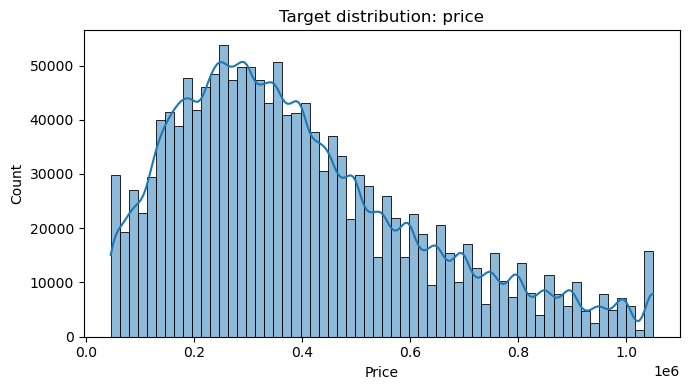

In [7]:
#plot the target distribution
plot_target_distribution(df)

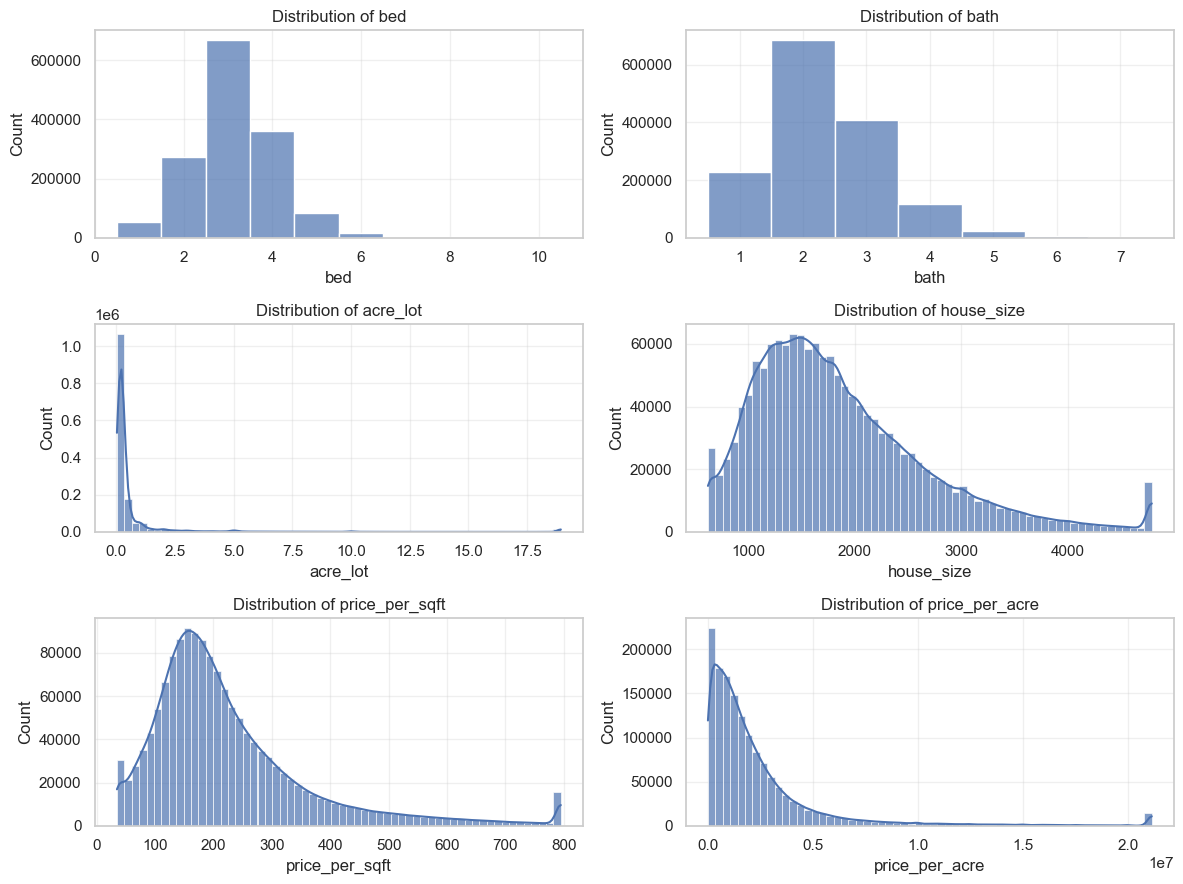

In [8]:
#plot the distribution of the numerical features
plot_numerical_data_distribution(df, numerical_features)

-- The main numerical variables are righ skewed, will perform a log-transformation to address this problem. 

In [9]:
#perform log transformation on the numerical features
df= log_transform(df)

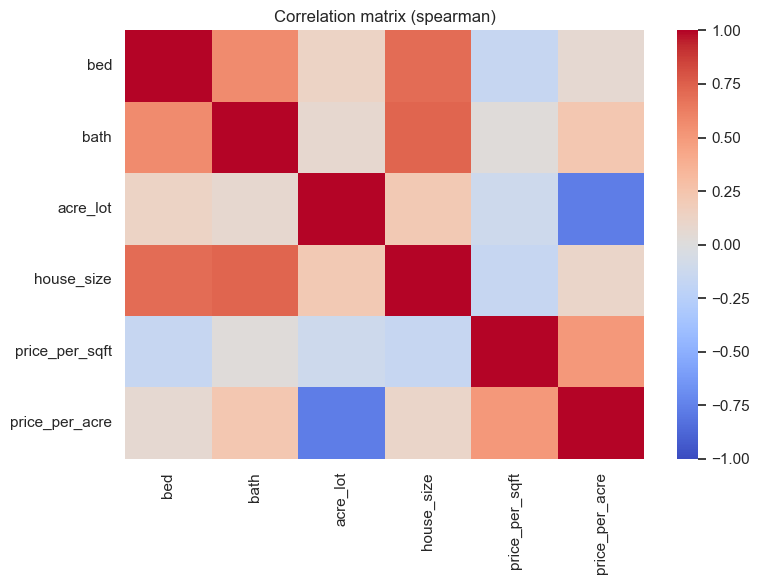

In [10]:
#plot the covariance matrix of the numerical features
plot_covariance_matrix(df, numerical_features)

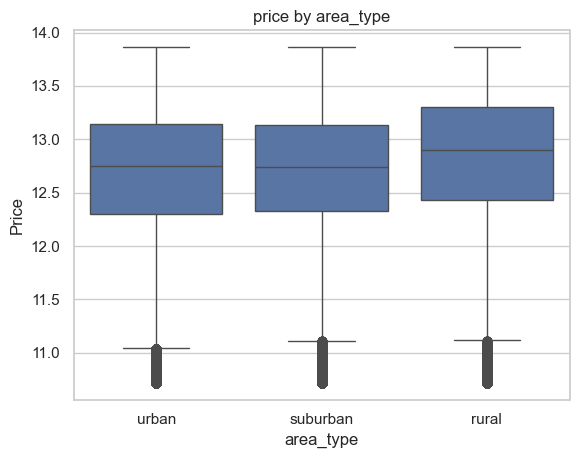

In [11]:
#plot the relationship between the categorical features and the target
plot_categorical_target_relationships(df, "area_type")

-- There is no much difference between categoical variables and the house price, probably it is not an important feature.

In [12]:
state_table, city_table = summarize_state_city(df)
state_table

,state,count
0,Florida,166588
1,Texas,151501
2,California,146671
3,Illinois,61916
4,Pennsylvania,56315
5,New York,55340
6,Arizona,53084
7,Georgia,52880
8,Virginia,51327
9,Washington,46502


In [13]:
city_table

,city,count
0,Houston,20152
1,Chicago,10920
2,Jacksonville,10494
3,Philadelphia,8442
4,Tucson,7904
...,...,...
17062,Pottawattamie Park,1
17063,Ogden Dunes,1
17064,Ora,1
17065,Etna Green,1


-- Some of the cities and states are rare and it adds up the dimensions, will group the tail cities and states into "other", respectively.

In [14]:
city_table.iloc[200]["count"]

1080

In [15]:
#change the city to "Other" if it is not in the top 199
top_199_cities = city_table.loc[:198, "city"]
df["city"] = df["city"].where(df["city"].isin(top_199_cities), "Other")

#change the state to "Other" if it is not in the top 51
top_51_states = state_table.loc[:50, "state"]
df["state"] = df["state"].where(df["state"].isin(top_51_states), "Other")


In [16]:
#save the dataframe to parquet file
df.to_parquet("data/USA Real Estate Dataset.parquet", index=False)